# Notebook 2 — Preprocessing & Modeling ML
## Projet : Return/Refund Propensity Classification — Olist E-Commerce

**Objectif :** Préparer les données puis entraîner les versions finales des modèles retenus
pour prédire le risque de retour/remboursement (`is_return_refund_risk`).

---
### Plan
1. Imports & Chargement
2. Preprocessing complet
3. Modèle 1 — Régression Logistique (version retenue)
4. Modèle 2 — Arbre de Décision (version retenue)
5. Modèle 3 — Random Forest (version retenue)
6. Modèle 4 — XGBoost (version retenue)
7. Comparaison des modèles retenus
8. Modèle final retenu
9. Analyse des features importantes
10. Analyse des erreurs
11. Conclusion

_Note : les essais multiples d'hyperparamètres sont documentés dans `brouillon_essai.ipynb`._

## 1. Imports & Chargement

In [20]:
# --- Librairies ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
import joblib  # Pour sauvegarder le modèle final

# --- Machine Learning : Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# XGBoost (bonus — commenter si non installé)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost non installé — pip install xgboost')

# --- Machine Learning : Optimisation & Évaluation ---
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)

# --- Configuration ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42  # Graine aléatoire pour la reproductibilité

# Forcer l'import du src local du projet en priorité
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

print('✅ Imports réussis')
print(f'Project root prioritaire: {project_root}')

✅ Imports réussis
Project root prioritaire: c:\Users\LENOVO\Desktop\MLProject


In [21]:
# Charger le DataFrame maître pré-généré
df = pd.read_csv('../data/master.csv')

print(f"Dataset chargé depuis master.csv : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset chargé depuis master.csv : 99,441 lignes × 22 colonnes


---
## 2. Preprocessing Complet

On utilise le pipeline de `src/preprocessing.py` qui enchaîne automatiquement toutes les étapes.

In [22]:
from src.preprocessing import full_preprocessing_pipeline

# Lance le pipeline complet : nettoyage → feature engineering → encodage → split → normalisation
X_train, X_test, y_train, y_test, scaler = full_preprocessing_pipeline(df)

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

PIPELINE DE PREPROCESSING

📅 Conversion des dates...
  ✅ 5 colonnes converties en datetime

🔍 Filtrage des commandes valides...
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes

🧹 Gestion des valeurs manquantes...
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'

⚙️  Feature Engineering...
  ✅ 8 nouvelles features créées : delivery_delay_days, processing_days, freight_ratio, price_per_item, was_delivered, review_missing, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :  13,506 (13.8%)
    Risque faible(0) :  84,206 (86.2%)

🔡 Enco

In [23]:
# Vérification du déséquilibre dans le train set
print('Distribution des classes dans y_train :')
print(y_train.value_counts())
print(f'\nRatio : {y_train.value_counts()[1] / y_train.value_counts()[0]:.2f}:1')

# NOTE : on utilisera class_weight='balanced' dans les modèles pour compenser

Distribution des classes dans y_train :
is_return_refund_risk
0    67364
1    10805
Name: count, dtype: int64

Ratio : 0.16:1


---
## 3. Modèle 1 — Régression Logistique (Version retenue)

Configuration choisie après essais dans `brouillon_essai.ipynb`.

In [24]:
print('=' * 50)
print('MODELE 1 - REGRESSION LOGISTIQUE')
print('=' * 50)

# Meilleur essai retenu: Trial 1
lr = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    C=1.0,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'\n{classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"])}')

MODELE 1 - REGRESSION LOGISTIQUE

Accuracy  : 0.7695
F1-Score  : 0.7955
AUC-ROC   : 0.7413

              precision    recall  f1-score   support

    Low Risk       0.92      0.80      0.86     16842
   High Risk       0.32      0.59      0.41      2701

    accuracy                           0.77     19543
   macro avg       0.62      0.69      0.64     19543
weighted avg       0.84      0.77      0.80     19543



---
## 4. Modèle 2 — Arbre de Décision (Version retenue)

Configuration choisie après essais dans `brouillon_essai.ipynb`.

In [25]:
print('=' * 50)
print('MODELE 2 - ARBRE DE DECISION')
print('=' * 50)

# Meilleur essai retenu: Trial 1
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    criterion='gini'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'\n{classification_report(y_test, y_pred_dt, target_names=["Low Risk", "High Risk"])}')

MODELE 2 - ARBRE DE DECISION

Accuracy  : 0.8377
F1-Score  : 0.8456
AUC-ROC   : 0.7632

              precision    recall  f1-score   support

    Low Risk       0.92      0.88      0.90     16842
   High Risk       0.43      0.55      0.48      2701

    accuracy                           0.84     19543
   macro avg       0.68      0.72      0.69     19543
weighted avg       0.86      0.84      0.85     19543



Module preprocessing utilisé: c:\Users\LENOVO\Desktop\MLProject\src\preprocessing.py
  ✅ 5 colonnes converties en datetime
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'
  ✅ 8 nouvelles features créées : delivery_delay_days, processing_days, freight_ratio, price_per_item, was_delivered, review_missing, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :  13,506 (13.8%)
    Risque faible(0) :  84,206 (86.2%)
  ✅ payment_type encodé → payment_type_encoded (6 modalités)
  ✅ customer_sta

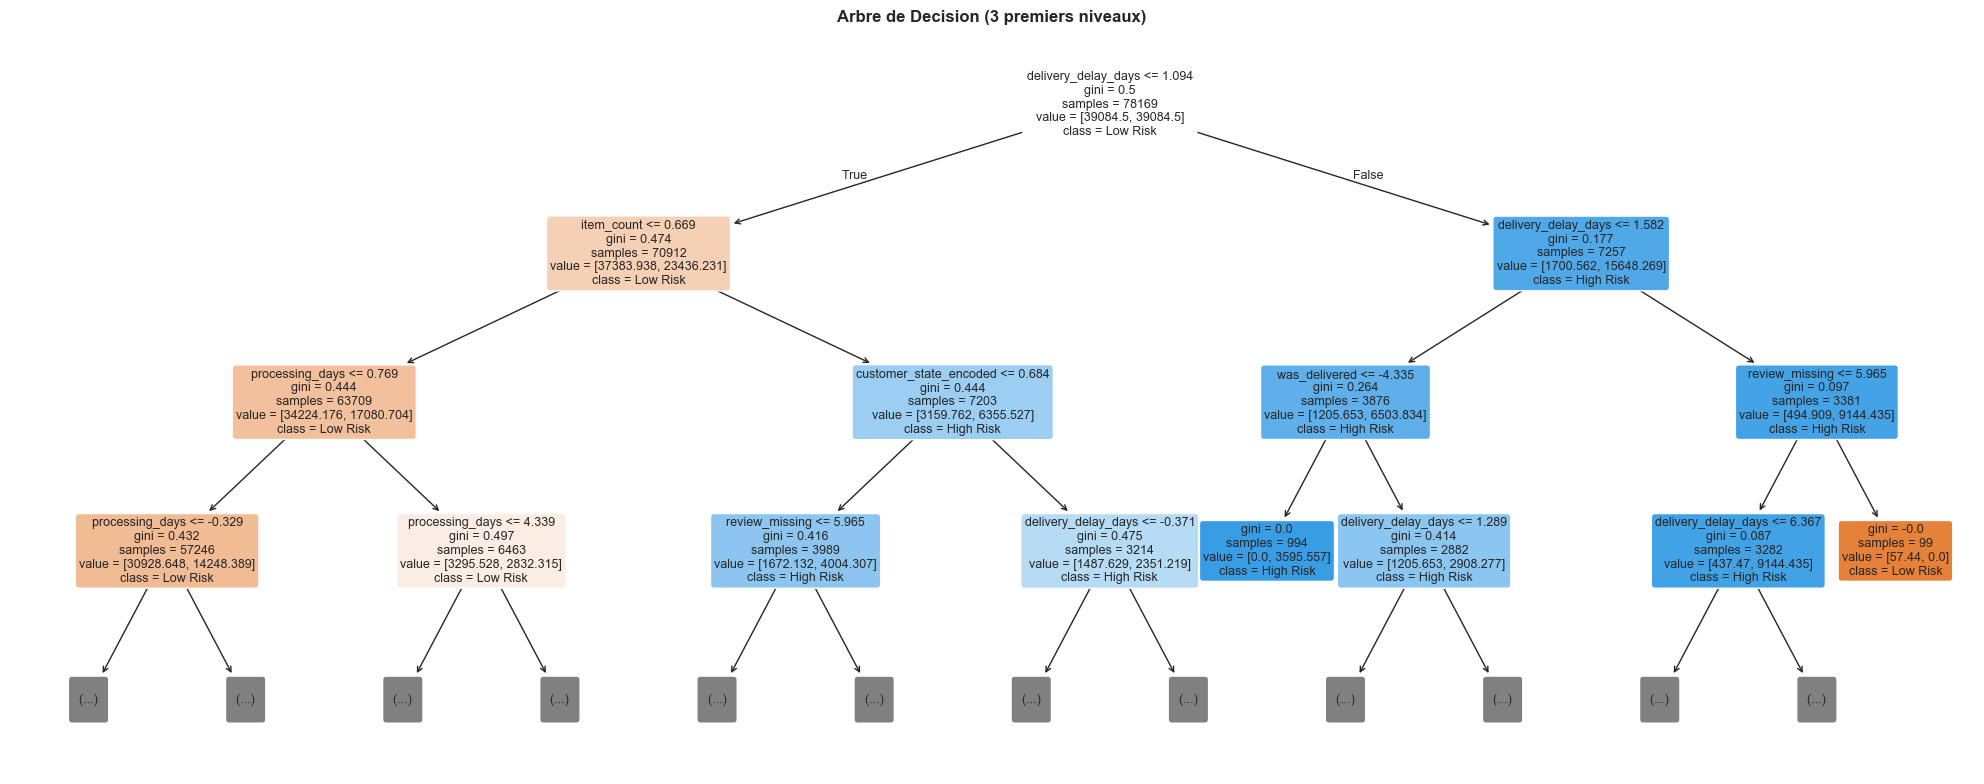

In [26]:
# Visualisation des 3 premiers niveaux de l'arbre
import importlib
import sys

# Forcer le rechargement pour éviter une version en cache d'un autre module src
if 'src.preprocessing' in sys.modules:
    del sys.modules['src.preprocessing']

import src.preprocessing as prep
importlib.reload(prep)
print(f"Module preprocessing utilisé: {prep.__file__}")

convert_dates = prep.convert_dates
filter_valid_orders = prep.filter_valid_orders
handle_missing_values = prep.handle_missing_values
create_features = prep.create_features
encode_categorical = prep.encode_categorical
select_features = prep.select_features

# Compatibilité entre versions du module
target_builder = getattr(prep, 'create_return_refund_target', None)
if target_builder is None:
    target_builder = prep.create_target

df_temp = convert_dates(df.copy())
df_temp = filter_valid_orders(df_temp)
df_temp = handle_missing_values(df_temp)
df_temp = create_features(df_temp)
df_temp = target_builder(df_temp)
df_temp = encode_categorical(df_temp)
X_named, _ = select_features(df_temp)
feature_names = X_named.columns.tolist()

plt.figure(figsize=(20, 8))
plot_tree(
    dt, max_depth=3,
    feature_names=feature_names,
    class_names=['Low Risk', 'High Risk'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Arbre de Decision (3 premiers niveaux)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Modèle 3 — Random Forest (Version retenue)

Configuration choisie après essais dans `brouillon_essai.ipynb`.

In [27]:
print('=' * 50)
print('MODELE 3 - RANDOM FOREST')
print('=' * 50)

# Meilleur essai retenu: Trial 3
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='log2',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"])}')

MODELE 3 - RANDOM FOREST

Accuracy  : 0.8791
F1-Score  : 0.8727
AUC-ROC   : 0.7741

              precision    recall  f1-score   support

    Low Risk       0.92      0.95      0.93     16842
   High Risk       0.58      0.45      0.51      2701

    accuracy                           0.88     19543
   macro avg       0.75      0.70      0.72     19543
weighted avg       0.87      0.88      0.87     19543



---
## 6. Modèle 4 — XGBoost (Version retenue)

Configuration choisie après essais dans `brouillon_essai.ipynb`.

In [28]:
if XGBOOST_AVAILABLE:
    print('=' * 50)
    print('MODELE 4 - XGBOOST')
    print('=' * 50)

    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)

    # Meilleur essai retenu: Trial 3
    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
)

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

    print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}')
    print(f'F1-Score  : {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
    print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_xgb):.4f}')
    print(f'\n{classification_report(y_test, y_pred_xgb, target_names=["Low Risk", "High Risk"])}')
else:
    print('XGBoost non disponible. Installer avec : pip install xgboost')

MODELE 4 - XGBOOST

Accuracy  : 0.8542
F1-Score  : 0.8570
AUC-ROC   : 0.7670

              precision    recall  f1-score   support

    Low Risk       0.92      0.91      0.91     16842
   High Risk       0.47      0.52      0.50      2701

    accuracy                           0.85     19543
   macro avg       0.70      0.71      0.71     19543
weighted avg       0.86      0.85      0.86     19543



---
## 7. Comparaison des Modèles


📊 Tableau Comparatif des Modèles :
         model_name  accuracy       f1      auc
      Random Forest  0.879138 0.872744 0.774106
            XGBoost  0.854168 0.856969 0.766985
      Decision Tree  0.837691 0.845555 0.763207
Logistic Regression  0.769534 0.795461 0.741322


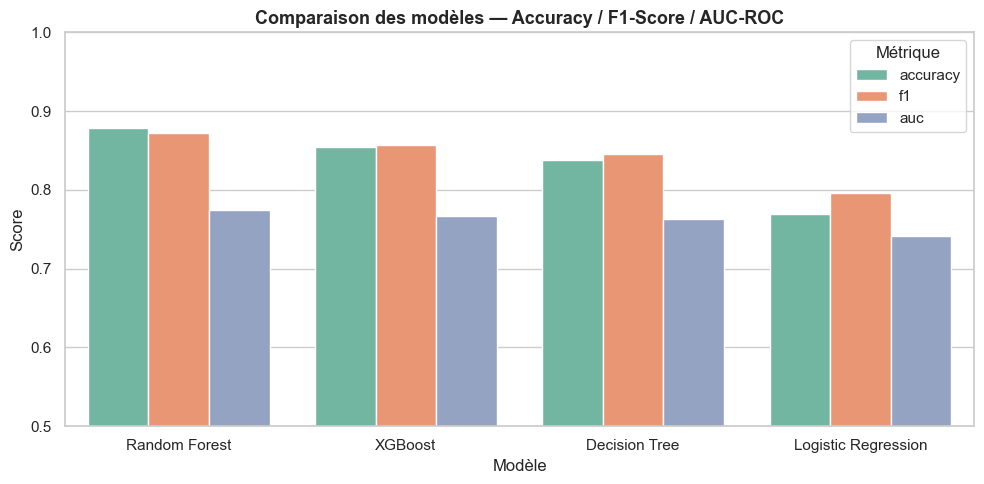

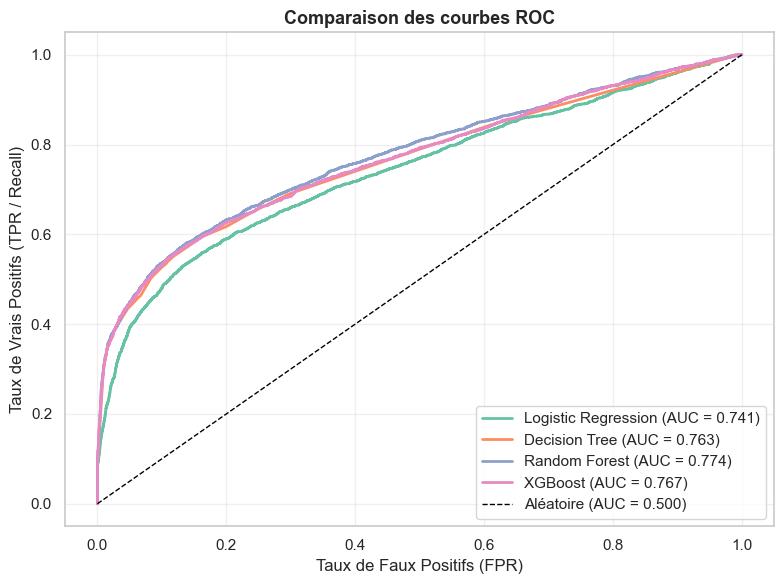

In [29]:
from src.evaluation import compare_models, plot_roc_curves

# Compilation des résultats de tous les modèles
results = [
    {'model_name': 'Logistic Regression',
     'accuracy': accuracy_score(y_test, y_pred_lr),
     'f1':       f1_score(y_test, y_pred_lr, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_lr)},

    {'model_name': 'Decision Tree',
     'accuracy': accuracy_score(y_test, y_pred_dt),
     'f1':       f1_score(y_test, y_pred_dt, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_dt)},

    {'model_name': 'Random Forest',
     'accuracy': accuracy_score(y_test, y_pred_rf),
     'f1':       f1_score(y_test, y_pred_rf, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_rf)},
]

if XGBOOST_AVAILABLE:
    results.append({
        'model_name': 'XGBoost',
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'f1':       f1_score(y_test, y_pred_xgb, average='weighted'),
        'auc':      roc_auc_score(y_test, y_proba_xgb)
    })

df_results = compare_models(results)

# Courbes ROC comparatives
models_dict = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
}
if XGBOOST_AVAILABLE:
    models_dict['XGBoost'] = xgb

plot_roc_curves(models_dict, X_test, y_test)

---
## 8. Modèle final retenu (Random Forest)

Le meilleur compromis retenu pour ce notebook final est un **Random Forest**
avec la configuration choisie après essais dans `brouillon_essai.ipynb`.

In [30]:
# Configuration finale retenue (issue des essais dans brouillon_essai.ipynb)
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='log2',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Entrainement du modele final Random Forest...')
best_rf.fit(X_train, y_train)
print('Modele final entraine.')

Entrainement du modele final Random Forest...
Modele final entraine.


In [31]:
# Evaluation du modele final sur le jeu de test
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print('Random Forest Final - Resultats Test Set :')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'  AUC-ROC  : {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'\n{classification_report(y_test, y_pred_best, target_names=["Low Risk", "High Risk"])}')

joblib.dump(best_rf, '../best_rf_model.joblib')
print('\nModele sauvegarde dans best_rf_model.joblib')

Random Forest Final - Resultats Test Set :
  Accuracy : 0.8791
  F1-Score : 0.8727
  AUC-ROC  : 0.7741

              precision    recall  f1-score   support

    Low Risk       0.92      0.95      0.93     16842
   High Risk       0.58      0.45      0.51      2701

    accuracy                           0.88     19543
   macro avg       0.75      0.70      0.72     19543
weighted avg       0.87      0.88      0.87     19543


Modele sauvegarde dans best_rf_model.joblib


---
## 9. Analyse des features importantes

Comprendre quelles variables influencent le plus le risque de retour/remboursement.

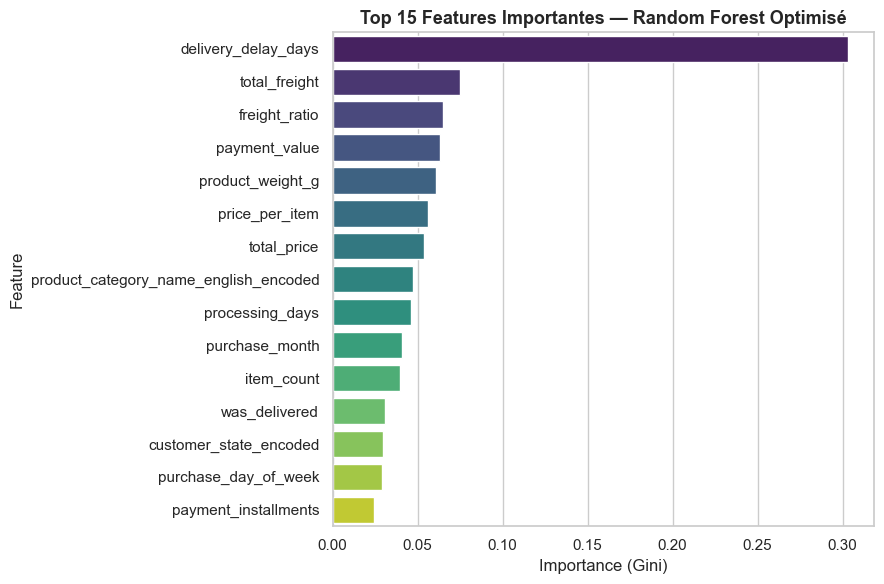

In [32]:
from src.evaluation import plot_feature_importance

# Visualisation des 15 features les plus importantes
plot_feature_importance(best_rf, feature_names, model_name='Random Forest Optimisé', top_n=15)

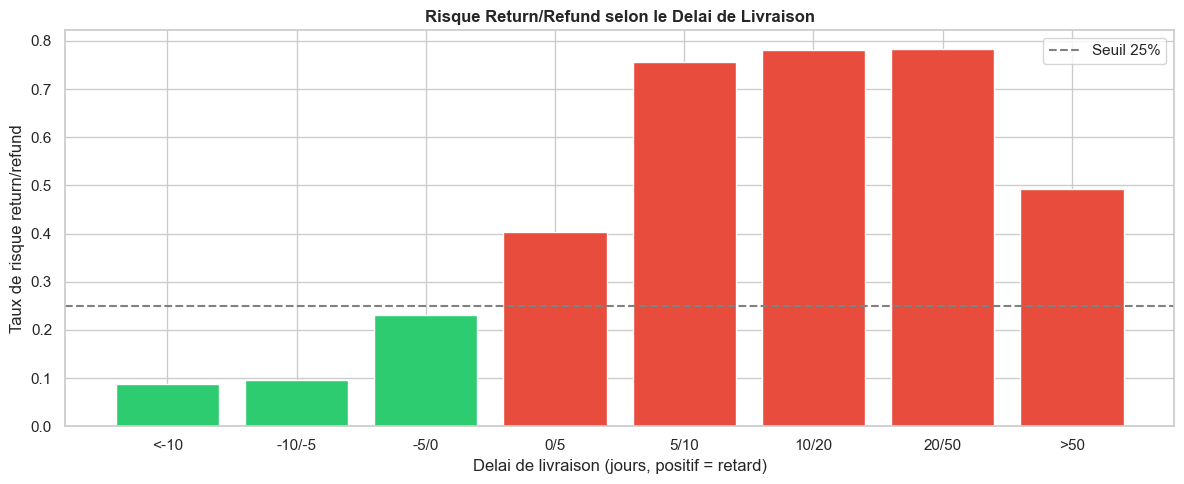


Insight : plus le retard augmente, plus le risque return/refund monte.


In [33]:
# Analyse : risque de retour/remboursement selon le delai de livraison
df_analysis = df_temp[df_temp['delivery_delay_days'].notna()].copy()

bins = [-30, -10, -5, 0, 5, 10, 20, 50, 100]
labels = ['<-10', '-10/-5', '-5/0', '0/5', '5/10', '10/20', '20/50', '>50']
df_analysis['delay_bucket'] = pd.cut(df_analysis['delivery_delay_days'], bins=bins, labels=labels)

risk_by_delay = df_analysis.groupby('delay_bucket')['is_return_refund_risk'].mean()

plt.figure(figsize=(12, 5))
plt.bar(
    risk_by_delay.index,
    risk_by_delay.values,
    color=['#e74c3c' if v > 0.25 else '#2ecc71' for v in risk_by_delay.values]
 )
plt.axhline(y=0.25, color='gray', linestyle='--', label='Seuil 25%')
plt.xlabel('Delai de livraison (jours, positif = retard)')
plt.ylabel('Taux de risque return/refund')
plt.title('Risque Return/Refund selon le Delai de Livraison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nInsight : plus le retard augmente, plus le risque return/refund monte.')

---
## 10. Analyse des erreurs

Comprendre les erreurs du modèle est essentiel pour le pilotage opérationnel.
- **Faux Positifs (FP)** : commandes prédites à haut risque alors qu'elles sont en faible risque
- **Faux Négatifs (FN)** : commandes prédites à faible risque alors qu'elles sont en haut risque

Dans ce cas d'usage, les **FN sont généralement les plus coûteux**
(on manque une commande réellement à risque).

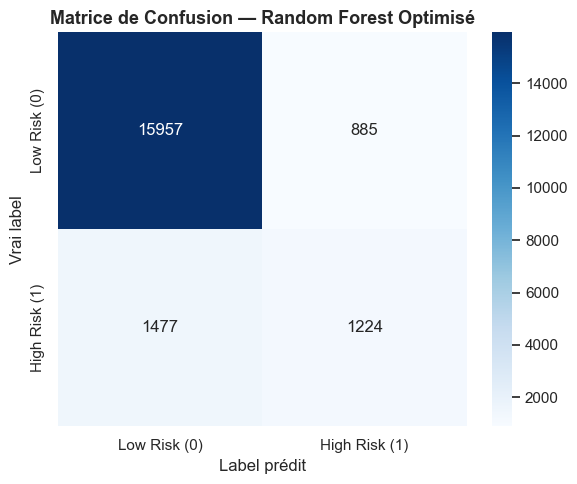

In [34]:
from src.evaluation import plot_confusion_matrix

# Matrice de confusion du meilleur modèle
plot_confusion_matrix(best_rf, X_test, y_test, model_name='Random Forest Optimisé')

In [35]:
# Analyse des cas mal classes
if isinstance(X_named, pd.DataFrame) and y_test.index.isin(X_named.index).all():
    # y_test.index contient des labels d'index, pas des positions -> utiliser loc
    X_test_df = X_named.loc[y_test.index].copy()
else:
    # Fallback robuste si l'index ne correspond pas ou si X_named n'est pas un DataFrame
    X_test_df = pd.DataFrame(X_test, index=y_test.index, columns=feature_names)

errors_mask = y_pred_best != y_test.values
print(f"Nombre total d'erreurs : {errors_mask.sum():,} ({errors_mask.sum()/len(y_test)*100:.1f}%)")

fp = ((y_pred_best == 1) & (y_test.values == 0)).sum()
fn = ((y_pred_best == 0) & (y_test.values == 1)).sum()
print(f"  Faux Positifs (FP) : {fp:,} - sur-allocation d'actions de mitigation")
print(f"  Faux Negatifs (FN) : {fn:,} - commandes a risque non detectees (cout eleve)")

Nombre total d'erreurs : 2,362 (12.1%)
  Faux Positifs (FP) : 885 - sur-allocation d'actions de mitigation
  Faux Negatifs (FN) : 1,477 - commandes a risque non detectees (cout eleve)


---
## 11. Conclusion

### 📊 Résumé des Performances

In [36]:
# Tableau final de comparaison
print('\n' + '='*65)
print('  BILAN FINAL — COMPARAISON DES MODÈLES')
print('='*65)
print(f'{"Modèle":<25} {"Accuracy":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('-'*65)
for r in results:
    print(f"{r['model_name']:<25} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}")
print('='*65)


  BILAN FINAL — COMPARAISON DES MODÈLES
Modèle                      Accuracy   F1-Score    AUC-ROC
-----------------------------------------------------------------
Logistic Regression           0.7695     0.7955     0.7413
Decision Tree                 0.8377     0.8456     0.7632
Random Forest                 0.8791     0.8727     0.7741
XGBoost                       0.8542     0.8570     0.7670


### Conclusions & Applicabilite Business

**Modele retenu :** Random Forest Final

**Facteurs cles du risque return/refund (ordre a valider a l'execution) :**
1. `delivery_delay_days`
2. `processing_days`
3. `freight_ratio`
4. `item_count`
5. `payment_installments`

**Applicabilite reelle :**
- Scorer chaque commande apres achat pour prioriser le suivi client.
- Alimenter les regles de fraud detection et de smart fulfillment.
- Déclencher des actions proactives sur les commandes a haut risque.

**Ameliorations possibles :**
- Ajouter des signaux temporels plus riches (week-end, saison, lead time vendeur).
- Tester calibration de probabilites et seuil de decision metier.
- Ajouter SHAP pour expliquer les predictions individuelles.
- Enrichir la cible avec une source explicite de retours/remboursements si disponible.